<a href="https://colab.research.google.com/github/leneeblot98-design/STAT-7110-Quality-Control/blob/main/Copy_of_STAT_7110_HW1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Homework 1 - Phase I & II Analysis Using Shewhart $\bar{X}$ and R/s Charts
### Dr. Austin Brown
### Kennesaw State University

**DUE: September 19, 2026 via D2L**

## Instructions:

A company called Blue Ridge Filament Co (BRFC) manufactures 1.75 mm PLA filament for 3D printers, selling to both hobbyist and small-manufacturing customers. Over the last quarter, customer support tickets describing clogging, stringing, and inconsistent print layers have risen sharply, and BRFC recently lost a wholesale account to a competitor over “inconsistent quality.” The plant manager has asked your quality control team to investigate Extruder Line 3, the line most frequently named in the complaint data, and to determine whether the line is running in a state of statistical control. This line is about six months away from needing its heating element replaced, but it could be replaced sooner if necessary.

The plant manager is particularly interested in the filament diameter produced (mm), measured inline by a laser micrometer as each spool is produced. Diameter that runs too thin causes under-extrusion and stringing; diameter that runs too thick causes jams and clogs in customers' print heads. Filament diameter is treated as a continuous, normally-distributed quality characteristic for this assignment.

Your team pulls a baseline (Phase I) sample of production data from Line 3: 5 spools sampled at random each week, for 25 consecutive weeks. After validating statistical control and process capability, the team can establish an ongoing monitoring plan for Phase II analysis.

## Key Specifications

| Quantity | Value |
|---|---|
| Target diameter | 1.750 mm |
| Lower Specification Limit (LSL) | 1.700 mm |
| Upper Specification Limit (USL) | 1.800 mm |
| Subgroup size (n) | 5 spools per week |
| Phase I subgroups (m) | 25 weeks |
| Phase II subgroups | 20 weeks |

## Define & Measure

### Q1: Briefly describe the purpose of this analysis

The purpose of this analysis is to investigate Extruder Line 3, the line most frequently named in the complaint data, and to determine whether the line is running in a state of statistical control.

### Q2: Identify the quality characteristic your team will monitor, classify its units and measurement scale.

The quality characteristic that will be monitored is the filament diameter produced in millimeters (mm), measured inline by a laser micrometer as each spool is produced. Diameter that runs too thin causes under-extrusion and stringing; diameter that runs too thick causes jams and clogs in customers' print heads. Filament diameter is treated as a continuous, normally-distributed quality characteristic on the measurement scale.


### Q3: Briefly describe why a Shewhart $\bar{X}$ and $R/s$ chart would be appropriate in this scenario. What are its limitations?

Filament diameter is treated as a continuous, normally-distributed quality characteristic on a ratio scale mentioned above. Shewhart charts are made for monitoring continuous variables. $\bar{X}$ and $R/s$ chart would be appropriate in this scenario because $\bar{X}$ helps us determine if the mean staying where it should be and $R/s$ tells us if the spread of the process staying stable. The limitations incluide us assuming that the data is normally distributed, Shewharts insensitivity to small shifts, the Diameter that runs too thin causes under-extrusion and stringing; diameter that runs too thick causes jams and clogs in customers' print heads.


## Analyze

### Q4: Read the Phase I data into R. Calculate and report the estimated process mean and standard deviation using both the $R$ and $s$ methods.


In [ ]:
# Clone your forked repository to Colab ##

## Specify your GitHub username:
user_name <- "leneeblot98-design"

## Specify the repository:
repo_name <- "STAT-7110-Quality-Control"

## Set the web address to your forked repository:
repo_address <- paste0(
  "https://github.com/",
  user_name,
  "/",
  repo_name,
  ".git"
)

## Check to see if repo is already cloned to Colab, and if not, clone repo:
if (!dir.exists(repo_name)) {
  system(paste("git clone", repo_address))
} else {
  print("Repository already cloned to Colab.")
}

[1] "Repository already cloned to Colab."


Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



Rows: 25
Columns: 6
$ Subgroup <dbl> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18…
$ Meas1    <dbl> 1.759712, 1.752064, 1.755094, 1.763434, 1.751915, 1.746336, 1…
$ Meas2    <dbl> 1.742690, 1.733264, 1.745186, 1.746130, 1.757228, 1.769405, 1…
$ Meas3    <dbl> 1.771452, 1.767347, 1.753372, 1.747787, 1.745419, 1.752795, 1…
$ Meas4    <dbl> 1.758564, 1.761277, 1.763998, 1.747608, 1.755608, 1.750858, 1…
$ Meas5    <dbl> 1.755669, 1.744550, 1.745075, 1.748262, 1.742620, 1.737254, 1…
[1] "--- Diagnostic Checks for qcc_data_input ---"
[1] "----------------------------------------"


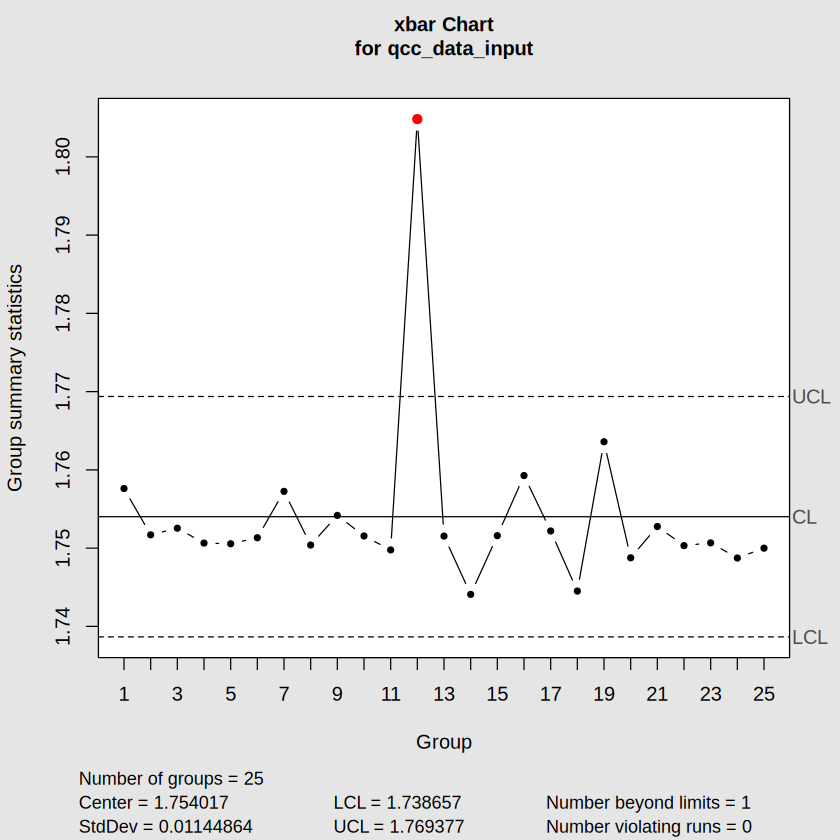

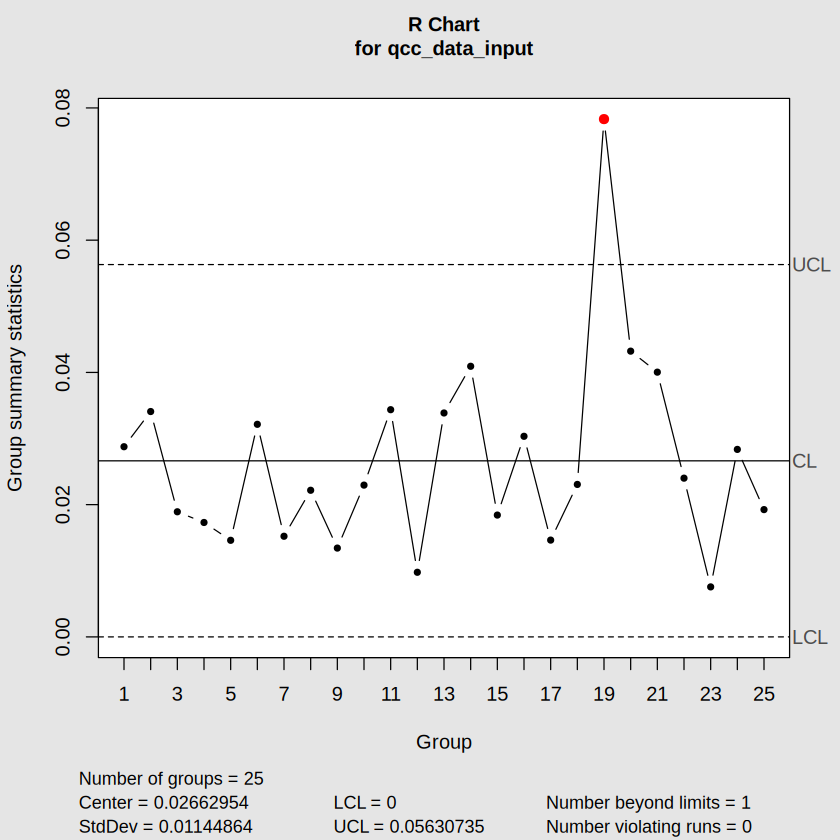


Call:
qcc(data = qcc_data_input, type = "xbar", sizes = 5, plot = TRUE)

xbar chart for qcc_data_input 

Summary of group statistics:
    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
1.744088 1.750324 1.751542 1.754017 1.752762 1.804824 

Group sample size:  5
Number of groups:  25
Center of group statistics:  1.754017
Standard deviation:  0.01144864 

Control limits:
      LCL      UCL
 1.738657 1.769377

Call:
qcc(data = qcc_data_input, type = "S", sizes = 5, plot = TRUE)

S chart for qcc_data_input 

Summary of group statistics:
       Min.     1st Qu.      Median        Mean     3rd Qu.        Max. 
0.003171372 0.006680901 0.009893827 0.010851993 0.013263603 0.037602024 

Group sample size:  5
Number of groups:  25
Center of group statistics:  0.01085199
Standard deviation:  0.01154485 

Control limits:
 LCL        UCL
   0 0.02266979


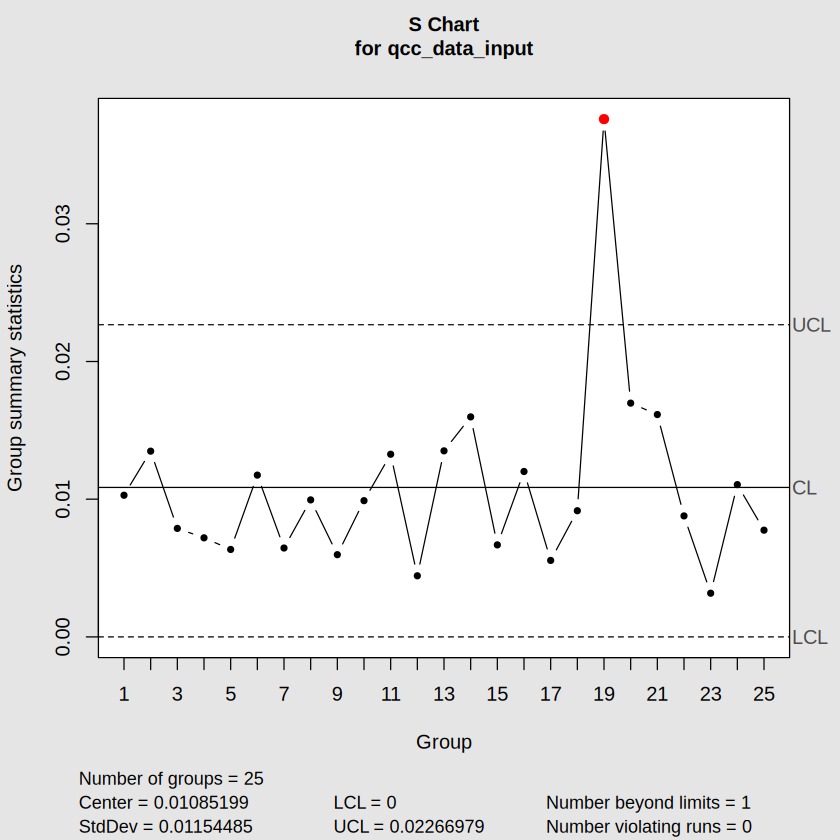

In [ ]:
## Q4 Code ##
## Install tidyverse, readxl, and qcc packages if necessary ##

install.packages(c("tidyverse", "readxl", "qcc"))

## Load the libraries ##

library(tidyverse)
library(readxl)
library(qcc)

## Read in the Phase 1 Data ##

phase_1_data <- read_excel("/content/STAT-7110-Quality-Control/Assignments/HW1/FilamentDiameter_PhaseI.xlsx")


## Data Integrity Check ##

phase_1_data |>
  glimpse()


# Prepare data for qcc function by selecting measurement columns and converting to a matrix
qcc_data_input <- as.matrix(phase_1_data |> select(starts_with("Meas")))

# --- Additional Diagnostic Checks for s-chart validity ---
print("--- Diagnostic Checks for qcc_data_input ---")

if (anyNA(qcc_data_input)) {
  print("Warning: qcc_data_input contains NA values.")
}
if (any(is.nan(qcc_data_input))) {
  print("Warning: qcc_data_input contains NaN values.")
}
if (any(is.infinite(qcc_data_input))) {
  print("Warning: qcc_data_input contains Inf or -Inf values.")
}

subgroup_sds <- apply(qcc_data_input, 1, sd)
if (any(subgroup_sds == 0)) {
  print("Warning: Some subgroups have zero standard deviation. This can cause the 'invalid s control chart' error.")
  print(paste("Subgroups with zero SD:", paste(which(subgroup_sds == 0), collapse = ", ")))
}
print("----------------------------------------")
# --- End Diagnostic Checks ---

## Save and plot phase 1 xbar and R charts ##

phase1_xbar <- qcc(qcc_data_input,
                   type = "xbar",
                   sizes = 5, # Re-adding sizes for explicit subgroup size
                   plot = TRUE)


phase1_r <- qcc(qcc_data_input,
                 type = "R",
                 sizes = 5, # Re-adding sizes for explicit subgroup size
                 plot = TRUE)


## Save and plot Phase 1 S Chart ##

phase1_s <- qcc(qcc_data_input,
                 type = "S",
                 sizes = 5, # Re-adding sizes for explicit subgroup size
                 plot = TRUE) # Changed back to TRUE to plot directly if successful

## View Summaries ##

summary(phase1_xbar)
summary(phase1_s)


### Q5: Construct a Phase I $R$ chart. Does the chart show evidence of statistical control? If not, identify the out-of-control subgroup(s) by number and provide a contextual explanation as to why these OOC points may have been observed, omit these points, and replot the chart until statistical control is observed.


The Phase I $R$ from question 4 charts, does not show evidence of statistical control. The out of control subgroup is subgroup 19 because it is way higher than the Upper Control Limit on the chart meaning the variance is too high in that week's sample data. Our case study states that the heating element on Extruder Line 3 is dying and I understandd that it can be replaced in 6 months but it needs to be replaced now because there is clearly a problem with it spiking in temperature. The temperature change in subgroup 19 during this test run per say, created inconsistencies in filament diameters for 5 spools that were sampled.


Call:
qcc(data = cleaned_matrix_q5, type = "R", sizes = 5, plot = TRUE)

R chart for cleaned_matrix_q5 

Summary of group statistics:
       Min.     1st Qu.      Median        Mean     3rd Qu.        Max. 
0.007561105 0.016783802 0.023007221 0.024476200 0.032579380 0.043216160 

Group sample size:  5
Number of groups:  24
Center of group statistics:  0.0244762
Standard deviation:  0.01052287 

Control limits:
 LCL        UCL
   0 0.05175418


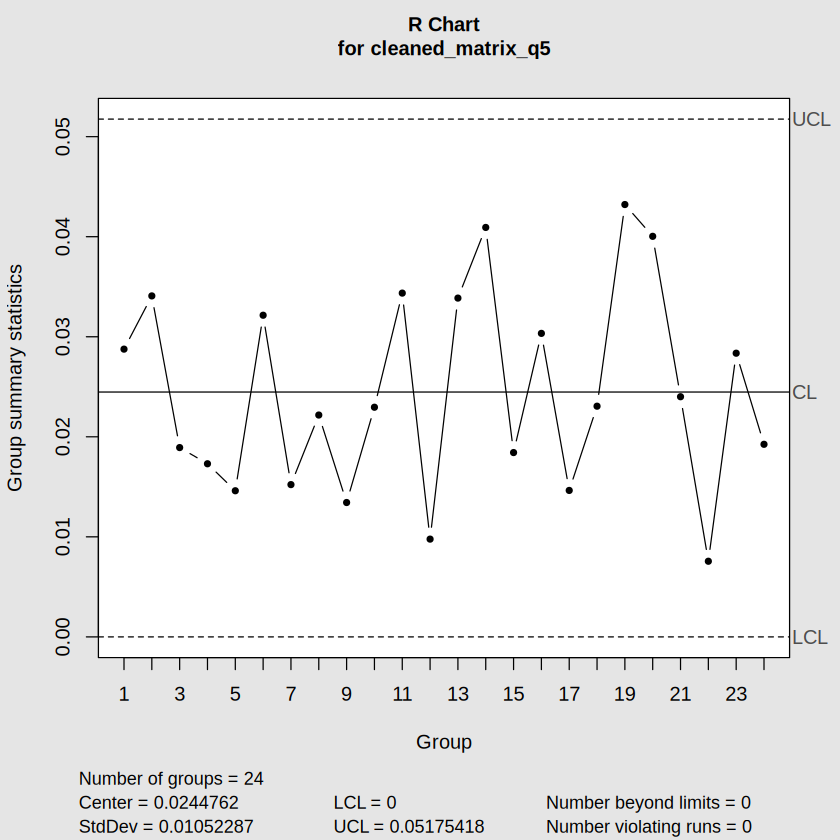

In [ ]:
## Q5 Code ##

## Filter out the out-of-control subgroup (Subgroup 19) ##
phase1_cleaned_q5 <- phase_1_data |>
  filter(Subgroup != 19)

## Prepare the cleaned matrix input ##
cleaned_matrix_q5 <- as.matrix(phase1_cleaned_q5 |> select(starts_with("Meas")))

## Replot the cleaned R Chart ##
cleaned_r_chart <- qcc(cleaned_matrix_q5,
                       type = "R",
                       sizes = 5,
                       plot = TRUE)

## View the updated summary to verify statistical control is achieved
summary(cleaned_r_chart)

### Q6: Using only the subgroups retained after Q5, construct the Phase I $\bar{X}$ chart. Does the chart show evidence of statistical control? If not, identify the out-of-control subgroup(s) by number and provide a contextual explanation as to why these OOC points may have been observed, omit these points, and replot the chart until statistical control is observed.


After removing the Subgroup 19 from the $\bar{R}$ chart and recalculating, the $\bar{X}$ chart still shows a Subgroup that is out of control, Subgroup 12. This subgroup surpasses the UCL on the $\bar{X}$ chart which means the average filament diameter in the data sample is higher than normal. This process mean shift can indicate a malfunction on Extruder 3 which likely causes the thickness malfunction.


Call:
qcc(data = matrix_q6, type = "xbar", sizes = 5, plot = TRUE)

xbar chart for matrix_q6 

Summary of group statistics:
    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
1.744088 1.750242 1.751436 1.753618 1.752599 1.804824 

Group sample size:  5
Number of groups:  24
Center of group statistics:  1.753618
Standard deviation:  0.01052287 

Control limits:
    LCL      UCL
 1.7395 1.767736


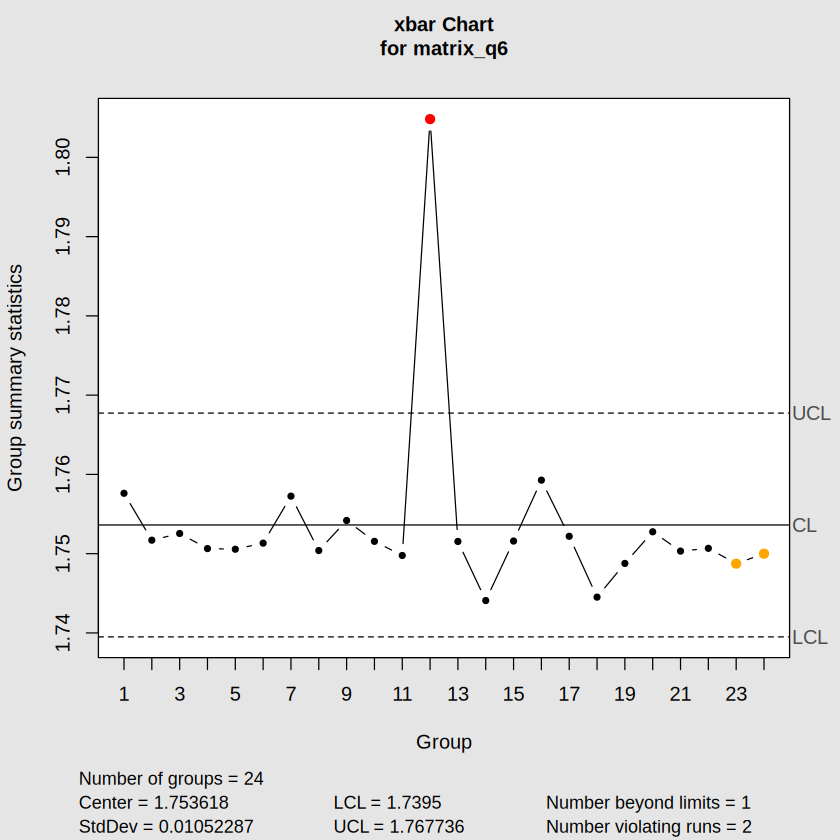

In [ ]:
## Q6 Code ##

# Filter out the out-of-control subgroup (Subgroup 19)
phase1_q6_data <- phase_1_data |>
  filter(Subgroup != 19)

## Prepare the matrix for Q6
matrix_q6 <- as.matrix(phase1_q6_data |> select(starts_with("Meas")))

## Construct and plot the Phase I X-bar chart
xbar_chart_q6 <- qcc(matrix_q6,
                     type = "xbar",
                     sizes = 5,
                     plot = TRUE)

## View the summary
summary(xbar_chart_q6)



Call:
qcc(data = matrix_q6_final, type = "xbar", sizes = 5, plot = TRUE)

xbar chart for matrix_q6_final 

Summary of group statistics:
    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
1.744088 1.750160 1.751329 1.751392 1.752369 1.759275 

Group sample size:  5
Number of groups:  23
Center of group statistics:  1.751392
Standard deviation:  0.01079771 

Control limits:
      LCL      UCL
 1.736905 1.765879


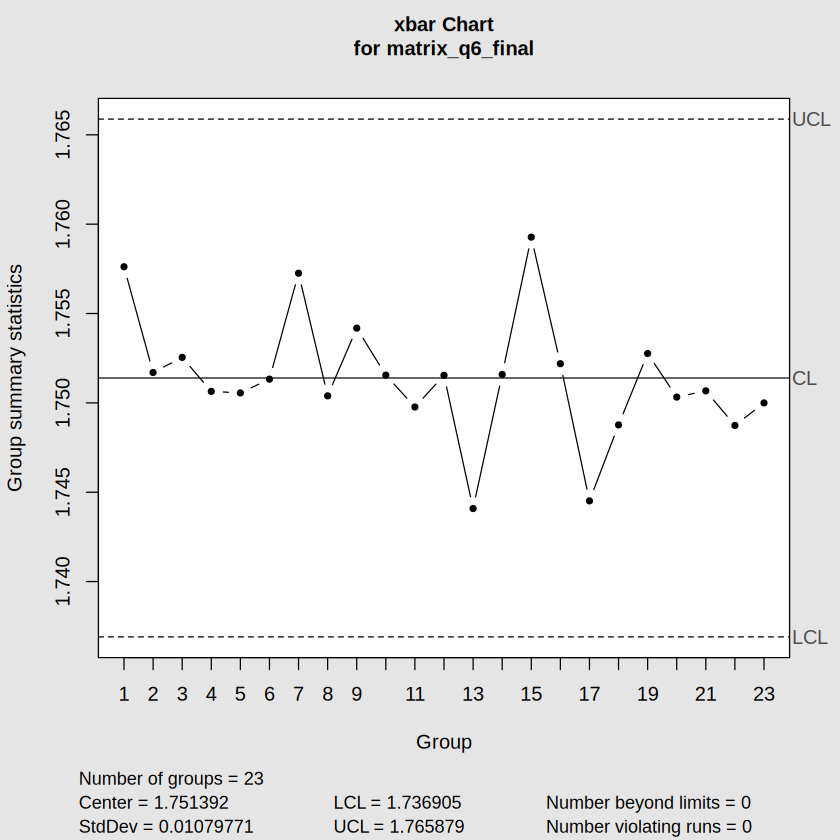

In [ ]:
## Question 6 code cleaned version

## Filter out both Subgroups 19 and 12
phase1_cleaned_q6 <- phase_1_data |>
  filter(!Subgroup %in% c(12, 19))

## Prepare the final cleaned matrix input
matrix_q6_final <- as.matrix(phase1_cleaned_q6 |> select(starts_with("Meas")))

## Replot the final X-bar Chart
final_xbar_chart <- qcc(matrix_q6_final,
                        type = "xbar",
                        sizes = 5,
                        plot = TRUE)


## Summary
summary(final_xbar_chart)

### Q7: Repeat the same process in Q4 - Q6 now using the $s$ chart instead of the $R$ chart

Initially in the $s$ chart, Subgroup 19 surpassed the UCL on the dispersion $s$ chart, similarly to the $\bar{R}$ chart, and Subgroup 12 surpassed the UCL on the $\bar{X}$ chart. This indication told us that that the $s$ chart was not in a state of statistical control.

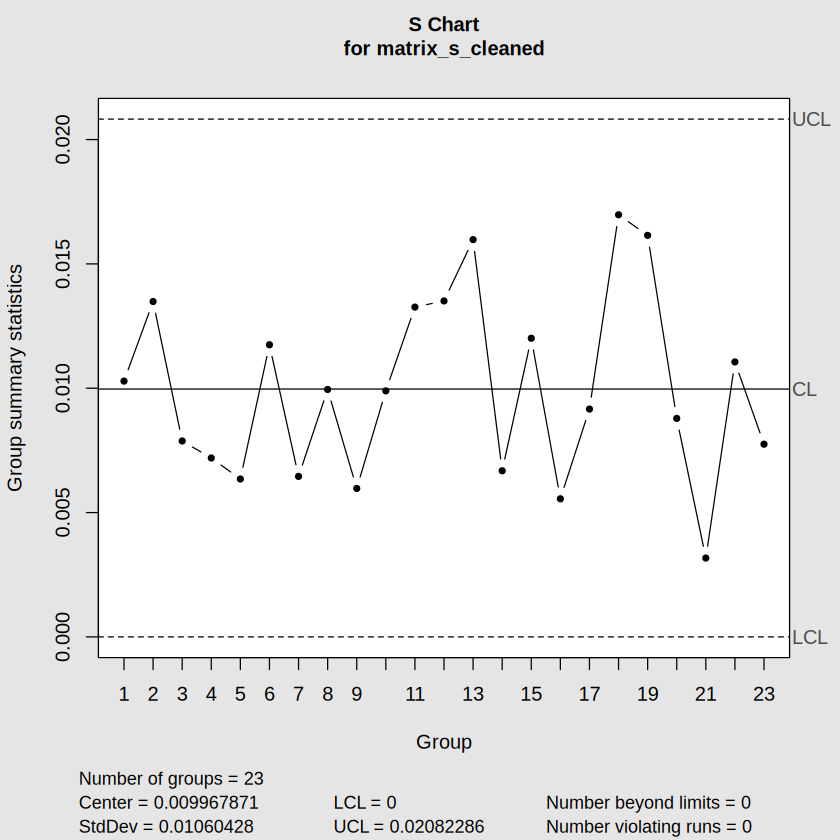


Call:
qcc(data = matrix_s_cleaned, type = "S", sizes = 5, plot = TRUE)

S chart for matrix_s_cleaned 

Summary of group statistics:
       Min.     1st Qu.      Median        Mean     3rd Qu.        Max. 
0.003171372 0.006937516 0.009893827 0.009967871 0.012637498 0.016976676 

Group sample size:  5
Number of groups:  23
Center of group statistics:  0.009967871
Standard deviation:  0.01060428 

Control limits:
 LCL        UCL
   0 0.02082286

Call:
qcc(data = matrix_s_cleaned, type = "xbar", sizes = 5, plot = TRUE)

xbar chart for matrix_s_cleaned 

Summary of group statistics:
    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
1.744088 1.750160 1.751329 1.751392 1.752369 1.759275 

Group sample size:  5
Number of groups:  23
Center of group statistics:  1.751392
Standard deviation:  0.01079771 

Control limits:
      LCL      UCL
 1.736905 1.765879


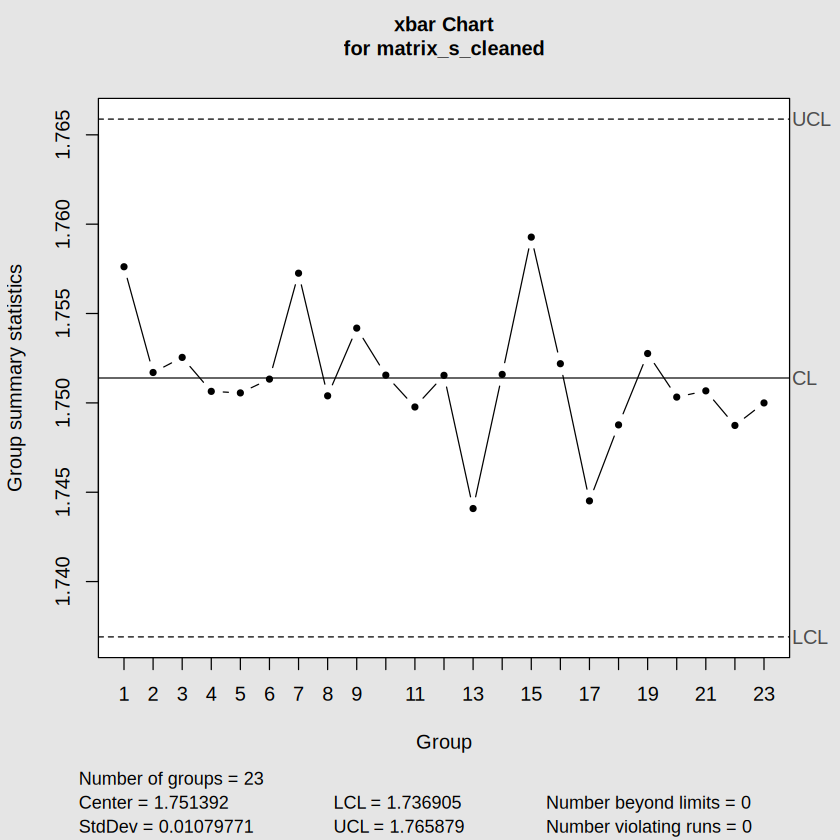

In [ ]:
## Q7 Code ##

## Read / verify data is loaded
phase_1_data <- read_excel("/content/STAT-7110-Quality-Control/Assignments/HW1/FilamentDiameter_PhaseI.xlsx")


## Filter out the identified OOC subgroups (12 and 19) to achieve statistical control
phase1_s_cleaned <- phase_1_data |>
  filter(!Subgroup %in% c(12, 19))


## Prepare the cleaned matrix input
matrix_s_cleaned <- as.matrix(phase1_s_cleaned |> select(starts_with("Meas")))


## Construct and plot the cleaned Phase I S Chart
cleaned_s_chart <- qcc(matrix_s_cleaned,
                       type = "S",
                       sizes = 5,
                       plot = TRUE)

 ## Construct and plot the corresponding X-bar Chart for the S-method
cleaned_xbar_s_chart <- qcc(matrix_s_cleaned,
                          type = "xbar",
                          sizes = 5,
                          plot = TRUE)
## Summaries
summary(cleaned_s_chart)
summary(cleaned_xbar_s_chart)


### Q8: Using your final Phase I estimates of the process mean and process standard deviation (using $s$ method), perform a process capability analysis against the specification limits given about. Report and interpret $FNC$, $C_p$, $C_{pk}$, and $C_{pm}$. Is the process capable of meeting specification? Is it well-centered?


Process Capability Analysis

Call:
process.capability(object = xbar_for_capability, spec.limits = c(1.7,     1.8), target = 1.75)

Number of obs = 115          Target = 1.75
       Center = 1.751           LSL = 1.7
       StdDev = 0.0108          USL = 1.8

Capability indices:

      Value   2.5%  97.5%
Cp    1.544  1.343  1.743
Cp_l  1.587  1.406  1.767
Cp_u  1.501  1.329  1.672
Cp_k  1.501  1.296  1.705
Cpm   1.531  1.332  1.730

Exp<LSL 0%	 Obs<LSL 0%
Exp>USL 0%	 Obs>USL 0%
$nobs
[1] 115

$center
[1] 1.751392

$std.dev
[1] 0.01079771

$target
[1] 1.75

$spec.limits
LSL USL 
1.7 1.8 

$indices
        Value     2.5%    97.5%
Cp   1.543537 1.343312 1.743446
Cp_l 1.586511 1.406283 1.766738
Cp_u 1.500563 1.329292 1.671833
Cp_k 1.500563 1.296481 1.704644
Cpm  1.530867 1.331543 1.729876

$exp
Exp < LSL Exp > USL 
        0         0 

$obs
Obs < LSL Obs > USL 
        0         0 



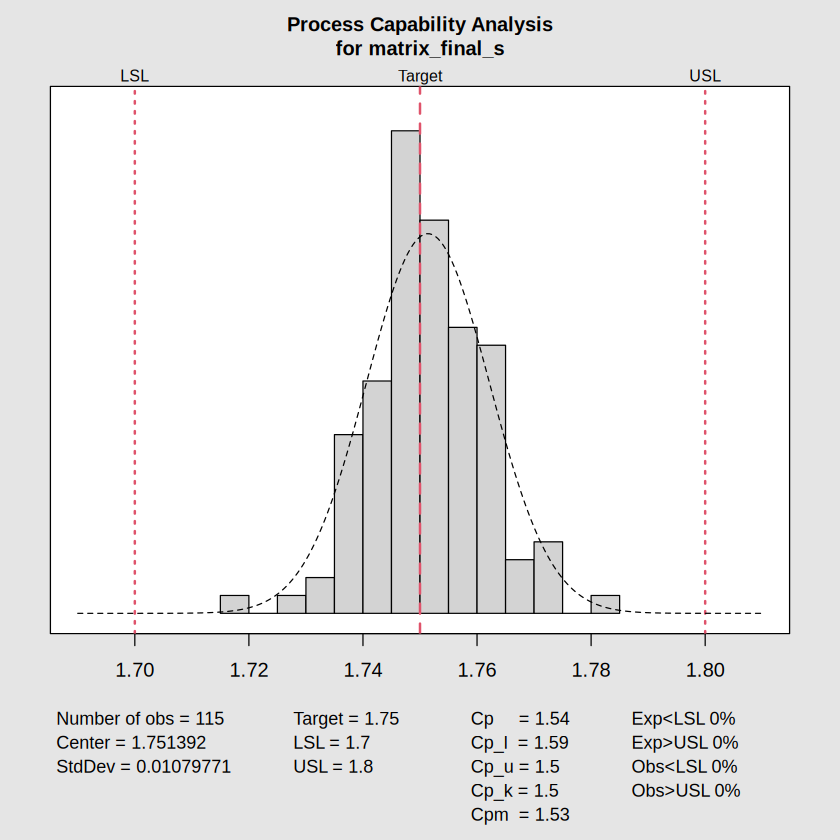

In [ ]:
## Q8 Code ##

## Ensure your final clean dataset from Q7 is ready (omitting subgroups 12 and 19)
phase1_final_s <- phase_1_data |>
  filter(!Subgroup %in% c(12, 19))

## re-create the final clean S-chart object to feed into the capability function
matrix_final_s <- as.matrix(phase1_final_s |> select(starts_with("Meas")))
final_s_chart_obj <- qcc(matrix_final_s, type = "S", sizes = 5, plot = FALSE)

## To perform process capability analysis with the s-method, we need the corresponding x-bar chart object.
## The 'cleaned_xbar_s_chart' object created in Q7 already uses the correct data and type.
## Re-creating it here for clarity within this cell, though it was already defined.
xbar_for_capability <- qcc(matrix_final_s, type = "xbar", sizes = 5, plot = FALSE)

## Perform Process Capability Analysis
# Specs given: Target = 1.750, LSL = 1.700, USL = 1.800
cap_analysis <- process.capability(xbar_for_capability,
                                   spec.limits = c(1.700, 1.800),
                                   target = 1.750)

 ## View capability summary metrics
print(cap_analysis)

## Question 8 Response

Based on the process capability analysis summaries outputted, we can see there are 0 defective spools produced from the $esp calculations. For Potential Capability, we have an estimate of 1.54 meaning, the potential spread is within the tolerance window. For the Actual Capability, we have an estimate of 1.5, which accounts for the process center while reflecting actual capability. For the Taguchi Index, we have an estimate of 1.53 meaning, their is some clustering around the target value. The process is extremely capable of meeting specification and well-centered especially because the center is estimated at 1.751 and the target is 1.750 with a standard deviation of 0.0108. Both the potential and actual capabilities comfortably meet the standard manufacturing threshold. Also the fraction non-conforming is 0% which means there is no variability in Extruder Line 3.

## Improve

### Q9: Briefly provide a contextual explanation as to leaving OOC points in the Phase I calculation of the control limits after identifying an assignable cause is not advisable.

Leaving OOC points in the Phase I calculation of the control limits after identifying an assignable cause is not advisable because it makes the limits too wide which stretches the UCL and LCL. Also, this does not help us in the future with finding other issues because they will fly under the radar undected due to the control limits.


## Control

### Q10: Read in the Phase II data into R. Using the finalized Phase I center line and control limits from Q7, construct the Phase II $\bar{X}$ chart. Do any subgroups plot outside the control limits?

I do not see any subgroups plotted outside the control limits indicating statistical control.


Call:
qcc(data = matrix_final_s, type = "xbar", sizes = 5, newdata = phase2_matrix,     plot = TRUE)

xbar chart for matrix_final_s 

Summary of group statistics:
    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
1.744088 1.750160 1.751329 1.751392 1.752369 1.759275 

Group sample size:  5
Number of groups:  23
Center of group statistics:  1.751392
Standard deviation:  0.01079771 

Summary of group statistics in phase2_matrix:
    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
1.743002 1.746417 1.748981 1.748609 1.750765 1.755127 

Group sample size:  5
Number of groups:  20 

Control limits:
      LCL      UCL
 1.736905 1.765879


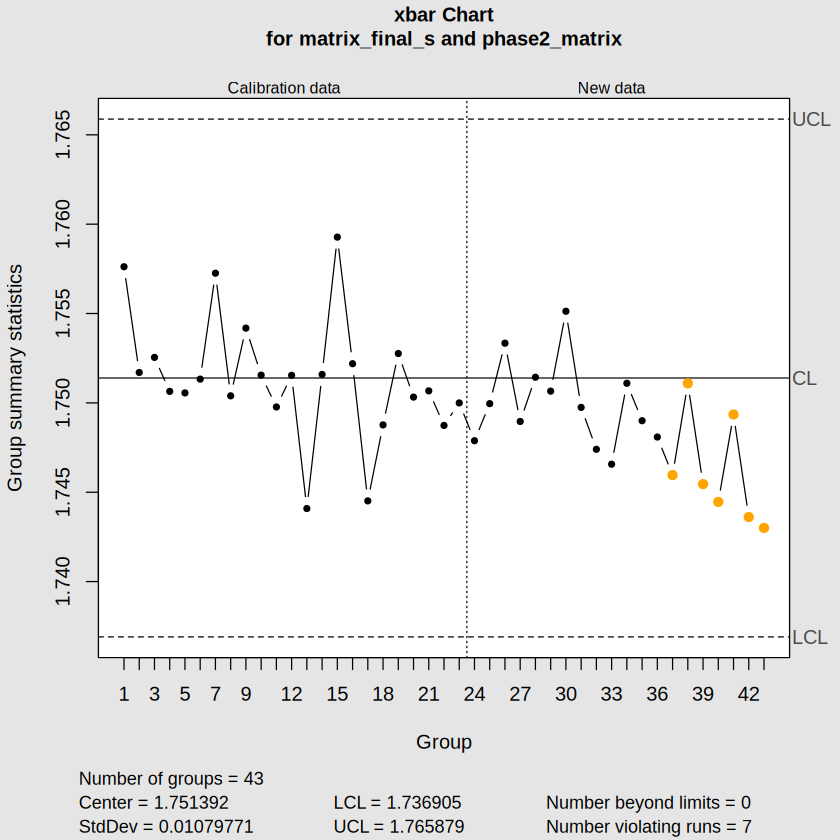

In [ ]:
## Q10 Code ##

## Read in the Phase II data file (update path if needed based on your folder structure)
phase_2_data <- read_excel("/content/STAT-7110-Quality-Control/Assignments/HW1/FilamentDiameter_PhaseII.xlsx")

## Convert Phase II measurements into a matrix format (just like Phase I)
phase2_matrix <- as.matrix(phase_2_data |> select(starts_with("Meas")))

## Construct the Phase II X-bar chart using your finalized, clean Phase I baseline data
# This applies your Phase I center line and control limits directly to the Phase II 'newdata'
phase2_xbar_chart <- qcc(matrix_final_s,
                         type = "xbar",
                         sizes = 5,
                         newdata = phase2_matrix,
                         plot = TRUE)

## Summary

summary(phase2_xbar_chart)


### Q11: Construct a Phase II $s$ chart. Do any subgroups plot outside the control limits?

No, there are no subgroups plotted outside of the control limits indicating stability in the process variability.


Call:
qcc(data = phase2_matrix, type = "S", sizes = 5, plot = TRUE)

S chart for phase2_matrix 

Summary of group statistics:
       Min.     1st Qu.      Median        Mean     3rd Qu.        Max. 
0.001773705 0.004386042 0.005614758 0.005871178 0.007174237 0.009891207 

Group sample size:  5
Number of groups:  20
Center of group statistics:  0.005871178
Standard deviation:  0.006246029 

Control limits:
 LCL        UCL
   0 0.01226488


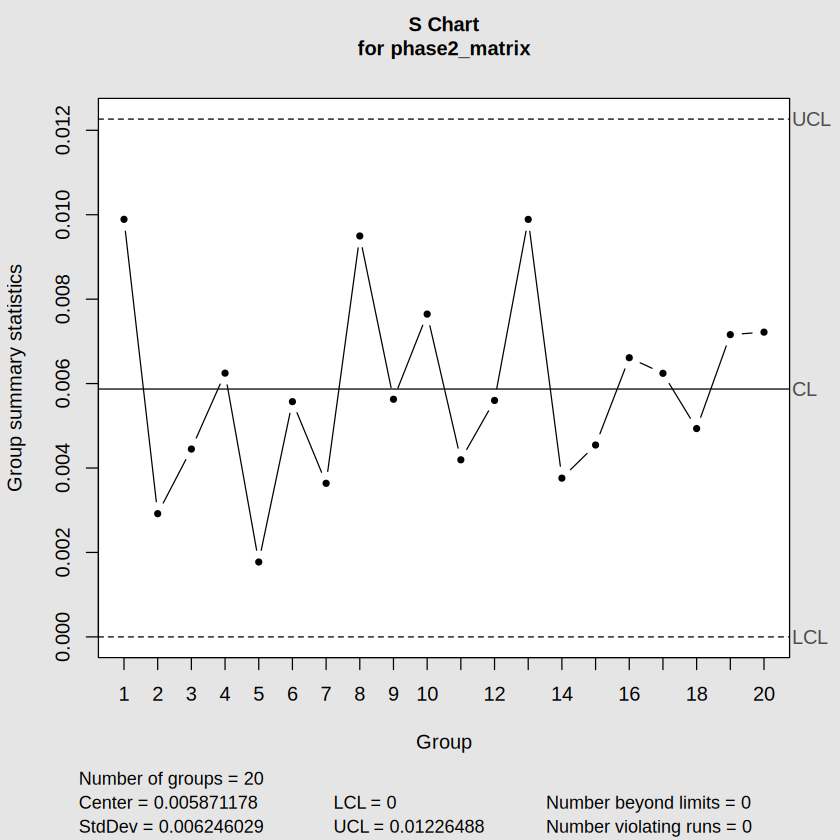

In [ ]:
## Q11 Code ##

## Construct the Phase II S chart
phase2_s_chart <- qcc(phase2_matrix,
                      type = "S",
                      sizes = 5,
                      plot = TRUE)

## Summary
summary(phase2_s_chart)

### Q12: Provide an overview of the results that the plant manager can provide the Vice President of Operations. Do they need to completely overhaul line 3 or is it salvagable?

Line 3 is salvageable and I don't believe it is a machine overall error it can possibly be a heating element default. Based on the capability measures, there seems to be no issues or defects outside of our specs.When the production data was ran against our final limits, everything returned stable which concludes Line 3 being in great shape. I do believe maintenence may need to be regulated frequently to avoid further issues.